# 1. Environment

## 1.1 Imports

### EDA & Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### ML Core

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

### Data Preparation

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

### Modeling

In [27]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve

### Optimization

In [59]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve

## 1.2 Read the Data 

In [ ]:
df = pd.read_csv("data/cleaned_data.csv")
df.head()

,account_id,month,company_size,industry,contract_type,discount_pct,regime_state,active_users,usage_growth,feature_adoption_rate,error_rate,tickets_count,ticket_growth,payment_delay_flag,current_mrr,next_month_mrr
0,0,1,SMB,Energy,Monthly,0.054167,stable,4,0.017574,0.002766,0.102689,0,0.0,0,112.703497,50.000000
1,0,2,SMB,Energy,Monthly,0.054167,stable,11,0.027244,0.000000,0.102174,2,0.0,1,50.000000,51.903945
2,0,3,SMB,Energy,Monthly,0.054167,decline,12,0.004655,0.082195,0.195298,2,0.0,0,51.903945,50.000000
3,0,4,SMB,Energy,Monthly,0.054167,decline,17,-0.024496,0.062898,0.104958,3,0.5,1,50.000000,55.680067
4,0,5,SMB,Energy,Monthly,0.054167,decline,20,-0.073376,0.120356,0.076803,0,-1.0,0,55.680067,50.000000


## 1.3 Printer Utilies

In [8]:
class Printer:

    RESET="\033[0m"
    BOLD="\033[1m"

    BLUE="\033[94m"
    CYAN="\033[96m"
    GREEN="\033[92m"
    YELLOW="\033[93m"
    RED="\033[91m"
    PURPLE="\033[95m"

    OK="✓"
    WARN="!"
    ERR="x"
    ARROW="→"
    STAR="★"
    BLOCK="■"

    @staticmethod
    def line():
        print(Printer.CYAN + "═"*80 + Printer.RESET)

    @staticmethod
    def section(title):
        Printer.line()
        print(f"{Printer.BOLD}{Printer.PURPLE}{title}{Printer.RESET}")
        Printer.line()

    @staticmethod
    def subsection(title):
        print(f"\n{Printer.CYAN}{Printer.BLOCK} {title}{Printer.RESET}")

    @staticmethod
    def info(msg):
        print(f"{Printer.BLUE}{Printer.ARROW} {msg}{Printer.RESET}")

    @staticmethod
    def success(msg):
        print(f"{Printer.GREEN}{Printer.OK} {msg}{Printer.RESET}")

    @staticmethod
    def warn(msg):
        print(f"{Printer.YELLOW}{Printer.WARN} {msg}{Printer.RESET}")

    @staticmethod
    def error(msg):
        print(f"{Printer.RED}{Printer.ERR} {msg}{Printer.RESET}")

    @staticmethod
    def metric(name,value):
        print(f"{Printer.BOLD}{Printer.CYAN}{name}:{Printer.RESET} {value}")

    @staticmethod
    def banner(text):
        Printer.line()
        print(f"{Printer.BOLD}{Printer.YELLOW}{text}{Printer.RESET}")
        Printer.line()

In [9]:
def print_table(df, title="Table"):

    styled = (
        df.style
        .background_gradient(cmap="YlGnBu")
        .format(precision=3)
        .set_caption(title)
        .set_table_styles([
            {
                "selector": "caption",
                "props": [("font-size", "15px"),("font-weight", "bold"),("color", "inherit"),("text-align", "center"),("padding", "10px"),],
            },
            {
                "selector": "th",
                "props": [("font-size", "12px"),("text-align", "center"),("border", "1px solid #888"),],
            },
            {
                "selector": "td",
                "props": [("border", "1px solid #888"),("text-align", "center"),("padding", "6px"),],
            },
            {
                "selector": "tr:hover",
                "props": [("background-color", "#ffff99")],
            },
        ])
    )

    display(styled)

## 1.4 Plot Theme

In [10]:
def set_plot_theme():

    plt.rcParams.update({

        "figure.facecolor":"#201335",
        "axes.facecolor":"#201335",
        "axes.edgecolor":"#7b2cbf",

        "axes.labelcolor":"#e0aaff",
        "xtick.color":"#c77dff",
        "ytick.color":"#c77dff",

        "grid.color":"#5a189a",
        "text.color":"#e0aaff",

        "font.size":11
    })

set_plot_theme()


## 1.5 Analysis Function

In [11]:
def analyze_numeric_feature(df, col, title):

    Printer.section(title)

    # Basic stats
    Printer.subsection("Basic Statistics")
    Printer.metric("Mean", round(df[col].mean(), 2))
    Printer.metric("Median", round(df[col].median(), 2))
    Printer.metric("Std", round(df[col].std(), 2))
    Printer.metric("Min", round(df[col].min(), 2))
    Printer.metric("Max", round(df[col].max(), 2))

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(14,10))

    # Histogram
    axes[0,0].hist(df[col], bins=60)
    axes[0,0].set_title(f"{col} Distribution")
    axes[0,0].grid(alpha=0.3)

    # KDE
    df[col].plot(kind="kde", ax=axes[0,1])
    axes[0,1].set_title(f"KDE of {col}")
    axes[0,1].grid(alpha=0.3)

    # Log Distribution (if positive)
    if (df[col] > 0).all():
        log_data = np.log1p(df[col])
        axes[1,0].hist(log_data, bins=60)
        axes[1,0].set_title(f"Log Distribution of {col}")
    else:
        axes[1,0].text(0.5, 0.5, "Log not applicable", ha='center')

    # Percentile Curve
    sorted_vals = np.sort(df[col])
    percentiles = np.linspace(0,100,len(sorted_vals))

    axes[1,1].plot(percentiles, sorted_vals)
    axes[1,1].set_title(f"{col} Percentile Curve")

    for ax in axes.flat:
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Insights
    Printer.subsection("Insights")

    skew = df[col].skew()

    if skew > 1:
        Printer.warn("Highly right-skewed distribution (long tail).")
    elif skew < -1:
        Printer.warn("Left-skewed distribution.")
    else:
        Printer.info("Approximately symmetric distribution.")

    Printer.info("Check outliers in top percentiles.")
    Printer.info("Consider transformation for modeling if skewed.")


## 1.6 Categorical Function

In [12]:
def analyze_categorical(df, col, title):

    Printer.section(title)
    Printer.subsection("Category Distribution")
    counts = df[col].value_counts()

    for k, v in counts.head(10).items():
        Printer.metric(k, v)

    plt.figure(figsize=(10,5))
    counts.head(10).plot(kind="bar")
    plt.title(f"{col} Distribution")
    plt.grid(alpha=0.3)
    plt.show()

    Printer.subsection("Insights")
    Printer.info("Check dominant categories.")
    Printer.warn("High imbalance may affect modeling.")


# 2. Feature Engineering

## 2.1 Define Targets

In [13]:
df["churn_flag"] = (df["next_month_mrr"] < df["current_mrr"]).astype(int)
df["churn_flag"].value_counts(normalize=True)

churn_flag
0    0.671392
1    0.328608
Name: proportion, dtype: float64

In [14]:
Printer.subsection("Churn Definition")
Printer.info("Churn is defined as revenue decline next month.")
Printer.warn("Includes both full churn and contraction.")
Printer.info("Binary classification problem is now ready.")


■ Churn Definition
→ Churn is defined as revenue decline next month.
! Includes both full churn and contraction.
→ Binary classification problem is now ready.


## 2.2 Feature Selection

In [15]:
features = [
    "company_size","industry","contract_type","regime_state",
    "discount_pct","active_users","usage_growth",
    "feature_adoption_rate","error_rate","tickets_count",
    "ticket_growth","payment_delay_flag","current_mrr"
]

X = df[features]
y = df["churn_flag"]

## 2.3 Encoding

In [16]:
cat_cols = ["company_size","industry","contract_type","regime_state"]
num_cols = [col for col in features if col not in cat_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3 Train First Model (Random Forest)

## 3.1 Train Model

In [17]:
model = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## 3.2 Model Evaluation

In [18]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85    154281
           1       0.71      0.65      0.68     75719

    accuracy                           0.80    230000
   macro avg       0.77      0.76      0.76    230000
weighted avg       0.79      0.80      0.79    230000



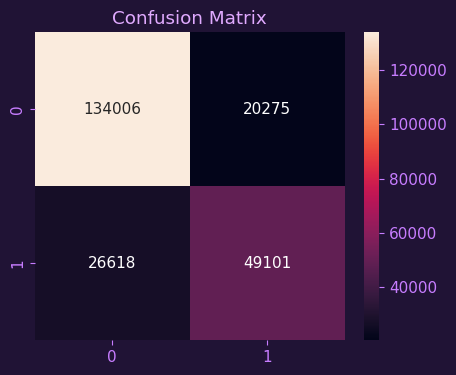

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [20]:
Printer.subsection("Model Performance")
Printer.info("Model predicts churn vs retention.")
Printer.info("Precision = how accurate churn predictions are.")
Printer.info("Recall = how many churn cases we catch.")
Printer.warn("Low recall = missing risky customers.")


■ Model Performance
→ Model predicts churn vs retention.
→ Precision = how accurate churn predictions are.
→ Recall = how many churn cases we catch.
! Low recall = missing risky customers.


## 3.3 ROC Curve

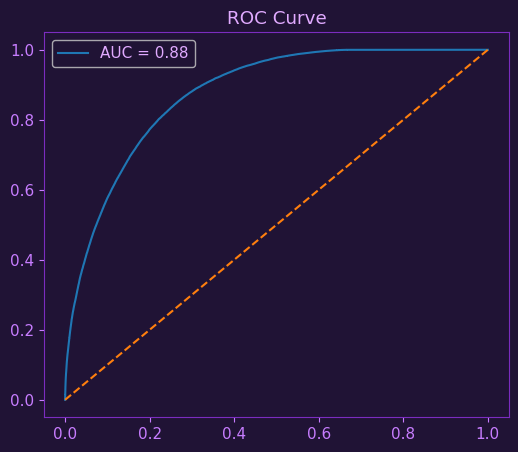

In [21]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [22]:
Printer.subsection("Model Quality")
Printer.info("AUC measures model ability to separate churn vs non-churn.")
Printer.info("Closer to 1 = strong model.")
Printer.warn("Near 0.5 = random guessing.")


■ Model Quality
→ AUC measures model ability to separate churn vs non-churn.
→ Closer to 1 = strong model.
! Near 0.5 = random guessing.


## 3.4 Churn Probability Scoring

In [23]:
df["churn_probability"] = model.predict_proba(X)[:,1]

high_risk = df[df["churn_probability"] > 0.7]
high_risk.head()

,account_id,month,company_size,industry,contract_type,discount_pct,regime_state,active_users,usage_growth,feature_adoption_rate,error_rate,tickets_count,ticket_growth,payment_delay_flag,current_mrr,next_month_mrr,churn_flag,churn_probability
4,0,5,SMB,Energy,Monthly,0.054167,decline,20,-0.073376,0.120356,0.076803,0,-1.000000,0,55.680067,50.000000,1,0.840809
6,0,7,SMB,Energy,Monthly,0.054167,stable,26,-0.029551,0.200939,0.121391,1,-0.750000,0,59.779118,50.000000,1,0.806067
11,0,12,SMB,Energy,Monthly,0.054167,decline,50,-0.033011,0.488579,0.117802,1,-0.888889,0,65.528626,50.000000,1,0.868612
14,0,15,SMB,Energy,Monthly,0.000000,stable,68,-0.031439,0.668169,0.161475,2,-0.666667,0,54.989430,50.000000,1,0.714451
27,1,5,Enterprise,Health,Monthly,0.029216,decline,69,0.001618,0.033877,0.033960,4,-0.500000,0,870.334781,650.030209,1,0.722627


In [24]:
Printer.subsection("Risk Segmentation")
Printer.info("Each account now has a churn probability score.")
Printer.warn("High-risk accounts should be prioritized.")
Printer.info("Enables proactive retention strategy.")


■ Risk Segmentation
→ Each account now has a churn probability score.
! High-risk accounts should be prioritized.
→ Enables proactive retention strategy.


## 3.5 Business Segemntation

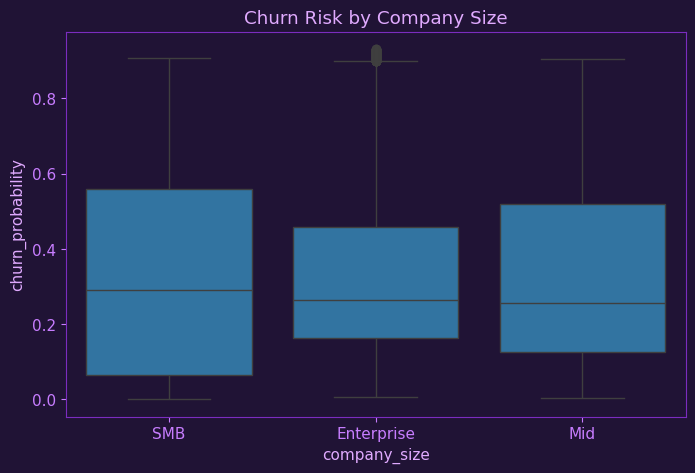

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="company_size",
    y="churn_probability"
)
plt.title("Churn Risk by Company Size")
plt.show()

In [26]:
Printer.subsection("Strategic Insight")
Printer.info("Different segments show different churn behavior.")
Printer.warn("Target retention strategies per segment.")


■ Strategic Insight
→ Different segments show different churn behavior.
! Target retention strategies per segment.


# 4. Upgrade Model (XGBoost)

## 4.1 Train Model

In [29]:
model = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [30]:
Printer.subsection("Model Upgrade")
Printer.info("XGBoost improves performance over Random Forest.")
Printer.info("Captures nonlinear relationships better.")
Printer.warn("More powerful but requires tuning.")


■ Model Upgrade
→ XGBoost improves performance over Random Forest.
→ Captures nonlinear relationships better.
! More powerful but requires tuning.


## 4.2 Hyperparameter Tuning (Grid Search)

In [40]:
param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [4, 6, 8],
    "clf__learning_rate": [0.05, 0.1, 0.2],
    "clf__subsample": [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [41]:
Printer.subsection("Model Optimization")
Printer.info("Hyperparameter tuning finds best configuration.")
Printer.info("Improves predictive accuracy.")
Printer.warn("Prevents underfitting and overfitting.")


■ Model Optimization
→ Hyperparameter tuning finds best configuration.
→ Improves predictive accuracy.
! Prevents underfitting and overfitting.


## 4.3 Handle Class Imbalance

In [42]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

model = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        scale_pos_weight=scale,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss"
    ))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## 4.4 Better Evaluation

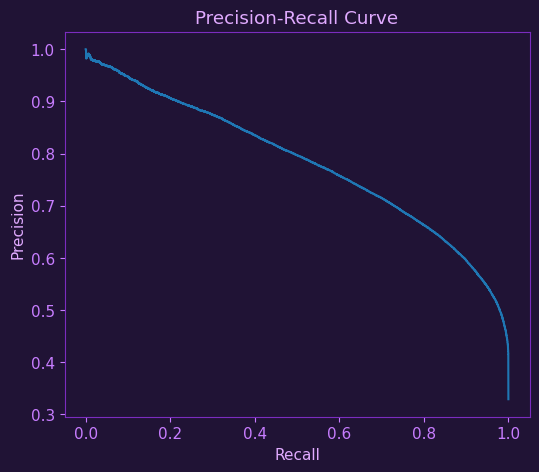

In [43]:
y_prob = model.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [44]:
Printer.subsection("Evaluation Upgrade")
Printer.info("Better metric for imbalanced data.")
Printer.info("Focuses on catching churn cases.")
Printer.warn("ROC alone is misleading for imbalance.")


■ Evaluation Upgrade
→ Better metric for imbalanced data.
→ Focuses on catching churn cases.
! ROC alone is misleading for imbalance.


## 4.5 Individual Prediction

In [45]:
sample_customer = X_test.iloc[[0]]
prob = model.predict_proba(sample_customer)[0][1]
print("Churn Probability:", prob)

Churn Probability: 0.8734314


In [46]:
Printer.subsection("Customer-Level Insight")
Printer.info("Each account gets a churn probability.")
Printer.warn("Used for targeted retention actions.")


■ Customer-Level Insight
→ Each account gets a churn probability.
! Used for targeted retention actions.


# 5. Business Impacts

## 5.1 Churn Risk Segments

In [47]:
df["churn_probability"] = model.predict_proba(X)[:,1]

def risk_segment(p):
    if p > 0.7:
        return "High Risk"
    elif p > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_segment"] = df["churn_probability"].apply(risk_segment)
df["risk_segment"].value_counts()

risk_segment
Low Risk       565894
High Risk      334834
Medium Risk    249272
Name: count, dtype: int64

In [48]:
Printer.subsection("Risk Segmentation")
Printer.info("Customers grouped into actionable segments.")
Printer.warn("High-risk accounts need immediate attention.")


■ Risk Segmentation
→ Customers grouped into actionable segments.
! High-risk accounts need immediate attention.


## 5.2 Business Layer

In [49]:
high_risk_accounts = df[df["risk_segment"] == "High Risk"]

high_risk_accounts[[
    "account_id",
    "company_size",
    "current_mrr",
    "tickets_count",
    "error_rate",
    "churn_probability"
]].head(10)

,account_id,company_size,current_mrr,tickets_count,error_rate,churn_probability
0,0,SMB,112.703497,0,0.102689,0.839160
4,0,SMB,55.680067,0,0.076803,0.966547
6,0,SMB,59.779118,1,0.121391,0.891823
9,0,SMB,53.771521,2,0.481068,0.771451
11,0,SMB,65.528626,1,0.117802,0.967613
14,0,SMB,54.989430,2,0.161475,0.845969
23,1,Enterprise,11402.900985,2,0.000000,0.814950
24,1,Enterprise,10973.381213,2,0.024319,0.853973
25,1,Enterprise,9626.188944,2,0.118414,0.890393
27,1,Enterprise,870.334781,4,0.033960,0.924473


In [50]:
Printer.subsection("Actionable Output")
Printer.info("List of accounts likely to churn.")
Printer.info("Prioritize high-value + high-risk customers.")
Printer.warn("This is where business value is created.")


■ Actionable Output
→ List of accounts likely to churn.
→ Prioritize high-value + high-risk customers.
! This is where business value is created.


# 6. Post-Modeling (Upgrade Business Impact)

## 6.1 Churn Probabilities

In [52]:
y_proba = model.predict_proba(X_test)[:, 1]
results = X_test.copy()

results["churn_probability"] = y_proba
results["actual"] = y_test.values

## 6.2 Create Risk Segments

In [ ]:
def risk_bucket(p):
    if p < 0.3:
        return "Low Risk"
    elif p < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

results["risk_segment"] = results["churn_probability"].apply(risk_bucket)

## 6.3 Business Value

In [74]:
results["current_mrr"] = df.loc[X_test.index, "current_mrr"]
results["revenue_at_risk"] = (
    results["current_mrr"] * results["churn_probability"]
)

In [ ]:
priority_accounts = results.sort_values(
    by="revenue_at_risk",
    ascending=False
)

In [77]:
results["risk_segment"] = results["churn_probability"].apply(risk_bucket)

## 6.4 Strategic Insights

In [78]:
summary = results.groupby("risk_segment").agg({
    "churn_probability": "mean",
    "current_mrr": "sum",
    "revenue_at_risk": "sum"
}).sort_values(by="revenue_at_risk", ascending=False)

print(summary)

              churn_probability   current_mrr  revenue_at_risk
risk_segment                                                  
High Risk              0.840622  3.218837e+07     2.708002e+07
Medium Risk            0.515164  2.304772e+07     1.189870e+07
Low Risk               0.075457  1.926315e+07     2.915100e+06


# 7. Actions

## 7.1 Rank by impact

In [79]:
high_risk = results[results["risk_segment"] == "High Risk"]
top_accounts = high_risk.sort_values(by="revenue_at_risk", ascending=False)

In [80]:
total_risk = summary["revenue_at_risk"].sum()
summary["risk_share"] = summary["revenue_at_risk"] / total_risk

## 7.2 Quantify opportunity

In [82]:
# Assume we can save 25%
save_rate = 0.25

high_risk["recoverable_revenue"] = high_risk["revenue_at_risk"] * save_rate

total_recovery = high_risk["recoverable_revenue"].sum()
print(total_recovery)

6770005.503907478


## 7.3 Break Risk by Segment Drivers

In [83]:
industry_risk = results.groupby("industry").agg({
    "revenue_at_risk": "sum"
}).sort_values(by="revenue_at_risk", ascending=False)

In [84]:
size_risk = results.groupby("company_size").agg({
    "revenue_at_risk": "sum"
}).sort_values(by="revenue_at_risk", ascending=False)

# 8. Decision Engine

## 8.1 Add Cost of Intervention

In [85]:
# Example cost per action
def intervention_cost(row):
    if row["churn_probability"] > 0.8:
        return 500   # expensive sales call
    elif row["churn_probability"] > 0.6:
        return 100   # discount / incentive
    else:
        return 20    # email / light touch

high_risk["intervention_cost"] = high_risk.apply(intervention_cost, axis=1)

## 8.2 Compute Net Value

In [87]:
# Calculate net value of intervention
high_risk["net_value"] = (
    high_risk["recoverable_revenue"] - high_risk["intervention_cost"]
)

# Filter for optimal targets
optimal_targets = high_risk.sort_values(
    by="net_value",
    ascending=False
)

# Filter for profitable targets
profitable_targets = optimal_targets[
    optimal_targets["net_value"] > 0
]

## 8.3 Final Business Metrics

In [88]:
total_revenue_at_risk = high_risk["revenue_at_risk"].sum()
total_recoverable = high_risk["recoverable_revenue"].sum()
total_cost = high_risk["intervention_cost"].sum()
total_profit = profitable_targets["net_value"].sum()

print("Revenue at risk:", total_revenue_at_risk)
print("Recoverable:", total_recoverable)
print("Cost:", total_cost)
print("Net profit:", total_profit)

Revenue at risk: 27080022.015629914
Recoverable: 6770005.503907478
Cost: 23882700
Net profit: 3053843.5576429516


## 8.4 Target only Top customers

In [89]:
top_1000 = profitable_targets.head(1000)
budget = 500000

selected = profitable_targets[
    profitable_targets["intervention_cost"].cumsum() <= budget
]

In [92]:
final_targets = profitable_targets[
    (profitable_targets["net_value"] > 0)
].sort_values("net_value", ascending=False)

final_targets = final_targets[
    final_targets["intervention_cost"].cumsum() <= budget
]

In [93]:
print("Selected Customers:", len(final_targets))
print("Total Cost:", final_targets["intervention_cost"].sum())
print("Expected Profit:", final_targets["net_value"].sum())
print("ROI:", final_targets["net_value"].sum() / final_targets["intervention_cost"].sum())

Selected Customers: 1368
Total Cost: 499600
Expected Profit: 2147633.1984455795
ROI: 4.298705361180103
